In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
#mypass = Path('/mnt/NAS-Ebanaru/sasaki/MTSingleBeads')
mypass = Path('/Volumes/data/Sasaki/MTSingleBeads')

def concatMSD(folder, interval_list, scale = 0.11):
    MSD_list = []
    num = 0
    for i in glob.glob(str(Path(folder) / "*" / "*" /"beads_tracks.csv")):
        MSD_df = {"exp":[], "MSD":[]} # Initialize an empty DataFrame to store the results
        IMSD, _ = dpm.get_msd(i, scale, interval_list[num], threshold = 0.0)
        emsd = IMSD.groupby('lag time').mean()['MSD']
        
        MSD_df["MSD"] = emsd
        MSD_df["exp"] = num

        MSD_list.append(pd.DataFrame(MSD_df))

        num +=1
    
    return pd.concat(MSD_list)

def calc_MSD(MSD_df):
    emsd = MSD_df.groupby('lag time').mean()['MSD'].astype(float)
    N = 1 + max(MSD_df["exp"])
    emsd_err = (MSD_df.groupby('lag time').std()['MSD'] / np.sqrt(N)).astype(float)

    return emsd, emsd_err, N

def fit(msd_df, min_t = 20, max_t = 144):
    # expごとにフィッティングを行う
    popt_list = []
    pcov_list = []
    for i in msd_df["exp"].unique():
        sub_df = msd_df[msd_df["exp"] == i]
        mask = (sub_df.index >= min_t) & (sub_df.index <= max_t)
        popt, pcov = curve_fit(fm.ln_pl, np.log10(np.float64(sub_df.index[mask])), np.log10(np.float64(sub_df["MSD"].to_numpy()[mask])))
        popt_list.append(popt)
        pcov_list.append(pcov)
    return np.array(popt_list), np.array(pcov_list)

def func(popt_list):
    mean = np.mean(popt_list, axis=0)
    err = np.std(popt_list, axis=0)/np.sqrt(popt_list.shape[0])
    return mean, err


def main():
    msd1um = concatMSD(mypass / "beads1um", [4, 4, 4, 4])
    msd3um = concatMSD(mypass / "beads3um", [4, 4, 4])
    msd5um = concatMSD(mypass / "beads5um", [4, 4, 4])
    msd7um = concatMSD(mypass / "beads7um", [4, 4, 4])
    msd20um = concatMSD(mypass / "beads20um", [4, 4, 4, 4])

    emsd_1um, err_1um, N_1um = calc_MSD(msd1um)
    emsd_3um, err_3um, N_3um = calc_MSD(msd3um)
    emsd_5um, err_5um, N_5um = calc_MSD(msd5um)
    emsd_7um, err_7um, N_7um = calc_MSD(msd7um)
    emsd_20um, err_20um, N_20um = calc_MSD(msd20um)

    scale = 0.11

    alpha = 1
    marker_size = 10
    
    min_t = 60
    max_t = 200

    popt_1um, pcov_1um = fit(msd1um, min_t, max_t)
    popt_3um, pcov_3um = fit(msd3um, min_t, max_t)
    popt_5um, pcov_5um = fit(msd5um, min_t, max_t)
    popt_7um, pcov_7um = fit(msd7um, min_t, max_t)
    popt_20um, pcov_20um = fit(msd20um, min_t, max_t)

    mean_popt_1um, err_popt_1um = func(popt_1um)
    mean_popt_3um, err_popt_3um = func(popt_3um)
    mean_popt_5um, err_popt_5um = func(popt_5um)
    mean_popt_7um, err_popt_7um = func(popt_7um)
    mean_popt_20um, err_popt_20um = func(popt_20um)

    fig, ax = plt.subplots()
    """
    ax.errorbar(emsd_1um.index, emsd_1um, yerr=err_1um, marker='o', label=f'1.18 \u03bcm, N={N_1um}', alpha = alpha, markersize = marker_size)
    ax.errorbar(emsd_3um.index, emsd_3um, yerr=err_3um, marker=10, label=f'3.37 \u03bcm, N={N_3um}', alpha = alpha, markersize = marker_size)
    ax.errorbar(emsd_5um.index, emsd_5um, yerr=err_5um, marker=11, label=f'5.00 \u03bcm, N={N_5um}', alpha = alpha, markersize = marker_size)
    ax.errorbar(emsd_7um.index, emsd_7um, yerr=err_7um, marker='*', label=f'7.24 \u03bcm, N={N_7um}', alpha = alpha, markersize = marker_size)  
    ax.errorbar(emsd_20um.index, emsd_20um, yerr=err_20um, marker='s', label=f'20.0 \u03bcm, N={N_20um}', alpha = alpha, markersize = marker_size)
    """

    ax.plot(emsd_1um.index, emsd_1um, marker='o', label=f'1.18 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[0])
    ax.fill_between(emsd_1um.index, emsd_1um - err_1um, emsd_1um + err_1um, edgecolor=style_colors[0], facecolor=mcolors.to_rgba(style_colors[0], alpha=0.2))
    ax.plot(emsd_3um.index, emsd_3um, marker='d', label=f'3.37 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[1])
    ax.fill_between(emsd_3um.index, emsd_3um - err_3um, emsd_3um + err_3um, edgecolor=style_colors[1], facecolor=mcolors.to_rgba(style_colors[1], alpha=0.2))
    ax.plot(emsd_5um.index, emsd_5um, marker=10, label=f'5.00 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[2])
    ax.fill_between(emsd_5um.index, emsd_5um - err_5um, emsd_5um + err_5um, edgecolor=style_colors[2], facecolor=mcolors.to_rgba(style_colors[2], alpha=0.2))
    ax.plot(emsd_7um.index, emsd_7um, marker=11, label=f'7.24 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[3])  
    ax.fill_between(emsd_7um.index, emsd_7um - err_7um, emsd_7um + err_7um, edgecolor=style_colors[3], facecolor=mcolors.to_rgba(style_colors[3], alpha=0.2))
    ax.plot(emsd_20um.index, emsd_20um, marker='s', label=f'20.0 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[4])
    ax.fill_between(emsd_20um.index, emsd_20um - err_20um, emsd_20um + err_20um, edgecolor=style_colors[4], facecolor=mcolors.to_rgba(style_colors[4], alpha=0.2))
    
    ax.legend()

    ax.plot([80,200], fm.power_law([80,200], 1 ,mean_popt_1um[1]*1e-1)*0.8 , label = f'{mean_popt_1um[1]:.2f}$\\times\\Delta t^{{{mean_popt_1um[0]:.2f}}}$', color='#333333')
    ax.text(130, 0.15, f'$\propto \Delta t^{{{1.0}}}$')

    ax.plot([80,200], fm.power_law([80,200], 2 ,mean_popt_1um[1]*1e-1)*8 , label = f'{mean_popt_1um[1]:.2f}$\\times\\Delta t^{{{mean_popt_1um[0]:.2f}}}$', color='#333333')
    ax.text(50, 200, f'$\propto \Delta t^{{{2.0}}}$')

    ax.set(
        xlim=(3.5e-0, 400),
        ylim=(1e-2, 1e3),
        xscale='log',
        yscale='log',
        xlabel='lag time $\Delta t$ [s]',
        ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
        )


    #fig.savefig(mypass / "figure" / "MSD.png", bbox_inches = 'tight')
    fig.savefig(mypass / "figure" / "MSD.pdf", bbox_inches = 'tight')

    fig2, ax2 = plt.subplots()
    ax2.errorbar([1.18, 3.37, 5.00, 7.24, 20.0], [mean_popt_1um[0], mean_popt_3um[0], mean_popt_5um[0], mean_popt_7um[0], mean_popt_20um[0]], yerr = [err_popt_1um[0], err_popt_3um[0], err_popt_5um[0], err_popt_7um[0], err_popt_20um[0]], marker='o')
    ax2.set(xlabel='Cargo Diameter $D_C$ [\u03bcm]', ylabel='$\\alpha$')

    #fig2.savefig(mypass / "figure" / "alpha.png", bbox_inches = 'tight')
    fig2.savefig(mypass / "figure" / "alpha.pdf", bbox_inches = 'tight')


/Users/sasakinozomu/code/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


[(1.0, 1000.0),
 (0.01, 1000.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta t$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ [μm$^2$]')]

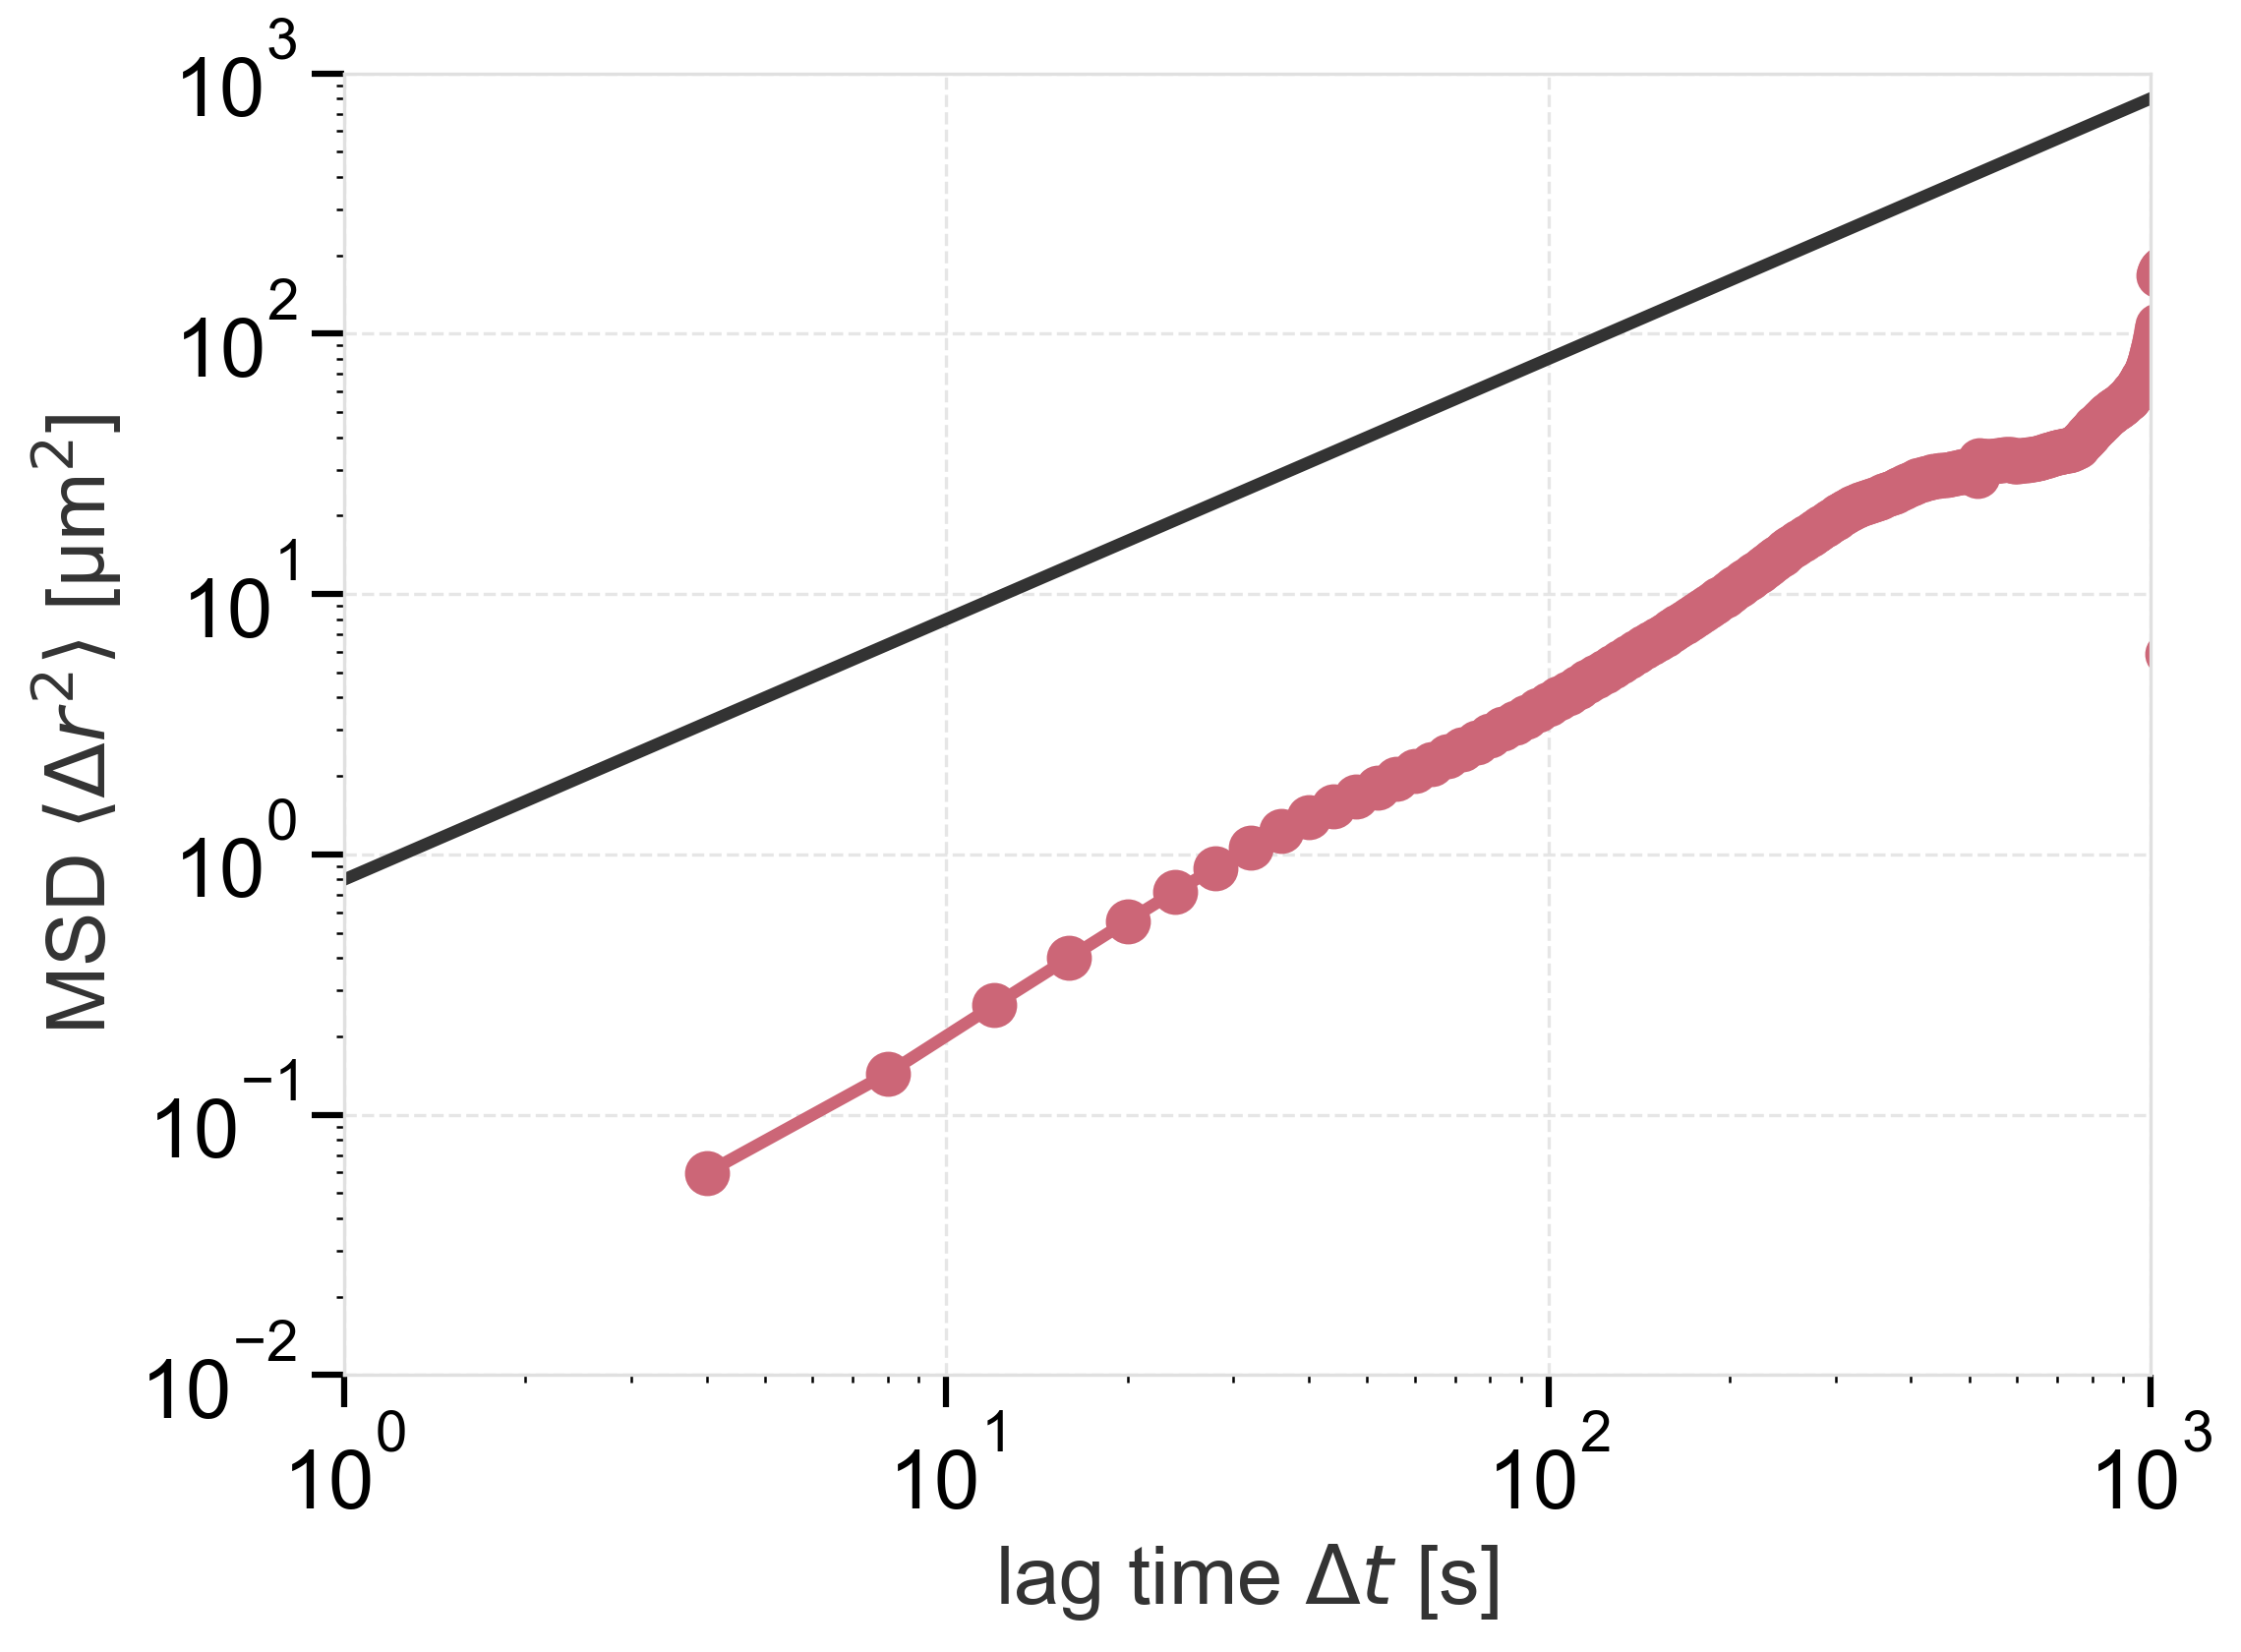

In [10]:
msd1um = concatMSD(mypass / "beads1um", [4, 4, 4, 4])
emsd_1um, err_1um, N_1um = calc_MSD(msd1um)
R=1


scale = 0.11

alpha = 1
marker_size = 10

min_t = 60
max_t = 200

D=0.2/R
x_range = np.linspace(1, 1e3, 1000)

popt_1um, pcov_1um = fit(msd1um, min_t, max_t)
mean_popt_1um, err_popt_1um = func(popt_1um)

fig, ax = plt.subplots()
ax.plot(emsd_1um.index, emsd_1um, marker='o', label=f'1.18 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[0])
ax.plot(x_range, 4*D*x_range, color="#333333")

ax.set(
        xlim=(1e-0, 1000),
        ylim=(1e-2, 1e3),
        xscale='log',
        yscale='log',
        xlabel='lag time $\Delta t$ [s]',
        ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
        )

[(1.0, 1000.0),
 (0.01, 1000.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta t$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ [μm$^2$]')]

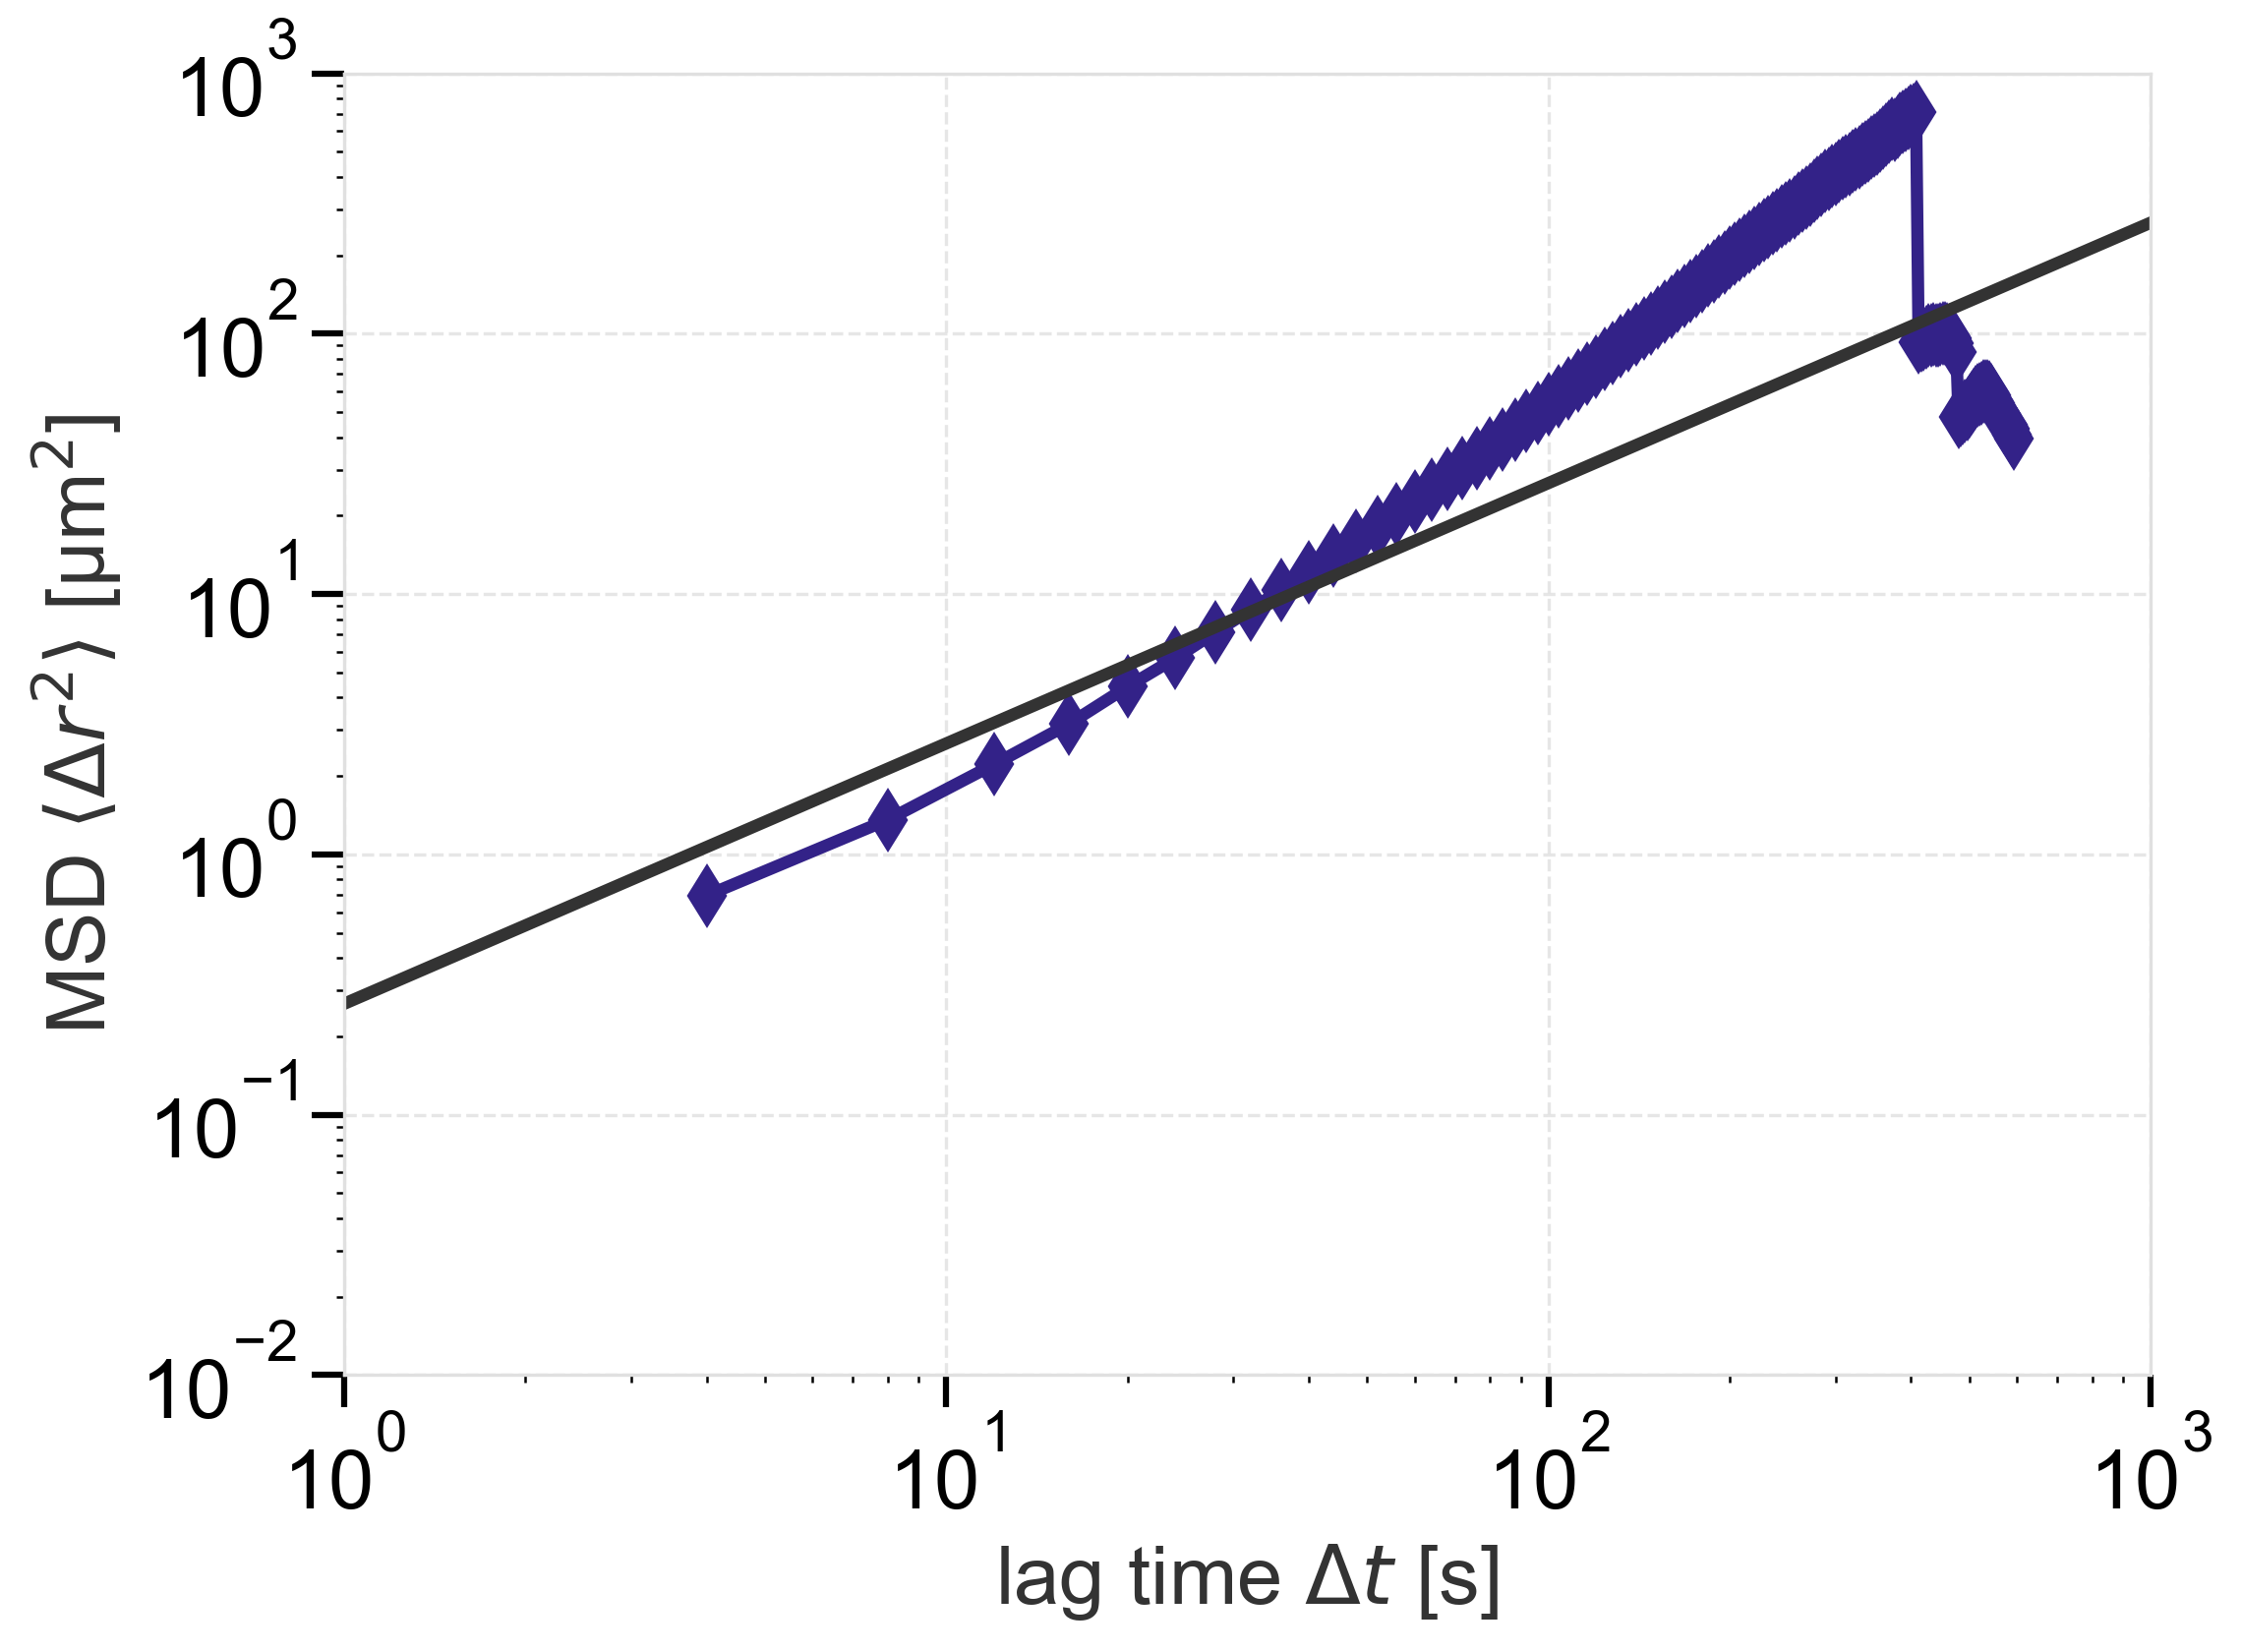

In [ ]:
msd3um = concatMSD(mypass / "beads3um", [4, 4, 4])
emsd_3um, err_3um, N_3um = calc_MSD(msd3um)
R=3

scale = 0.11

alpha = 1
marker_size = 10

min_t = 60
max_t = 200

D=0.2/R
x_range = np.linspace(1, 1e3, 1000)

fig, ax = plt.subplots()
ax.plot(emsd_3um.index, emsd_3um, marker='d', label=f'3.37 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[1])
ax.plot(x_range, 4*D*x_range, color="#333333")

ax.set(
        xlim=(1e-0, 1000),
        ylim=(1e-2, 1e3),
        xscale='log',
        yscale='log',
        xlabel='lag time $\Delta t$ [s]',
        ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
        )

[(1.0, 1000.0),
 (0.01, 1000.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta t$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ [μm$^2$]')]

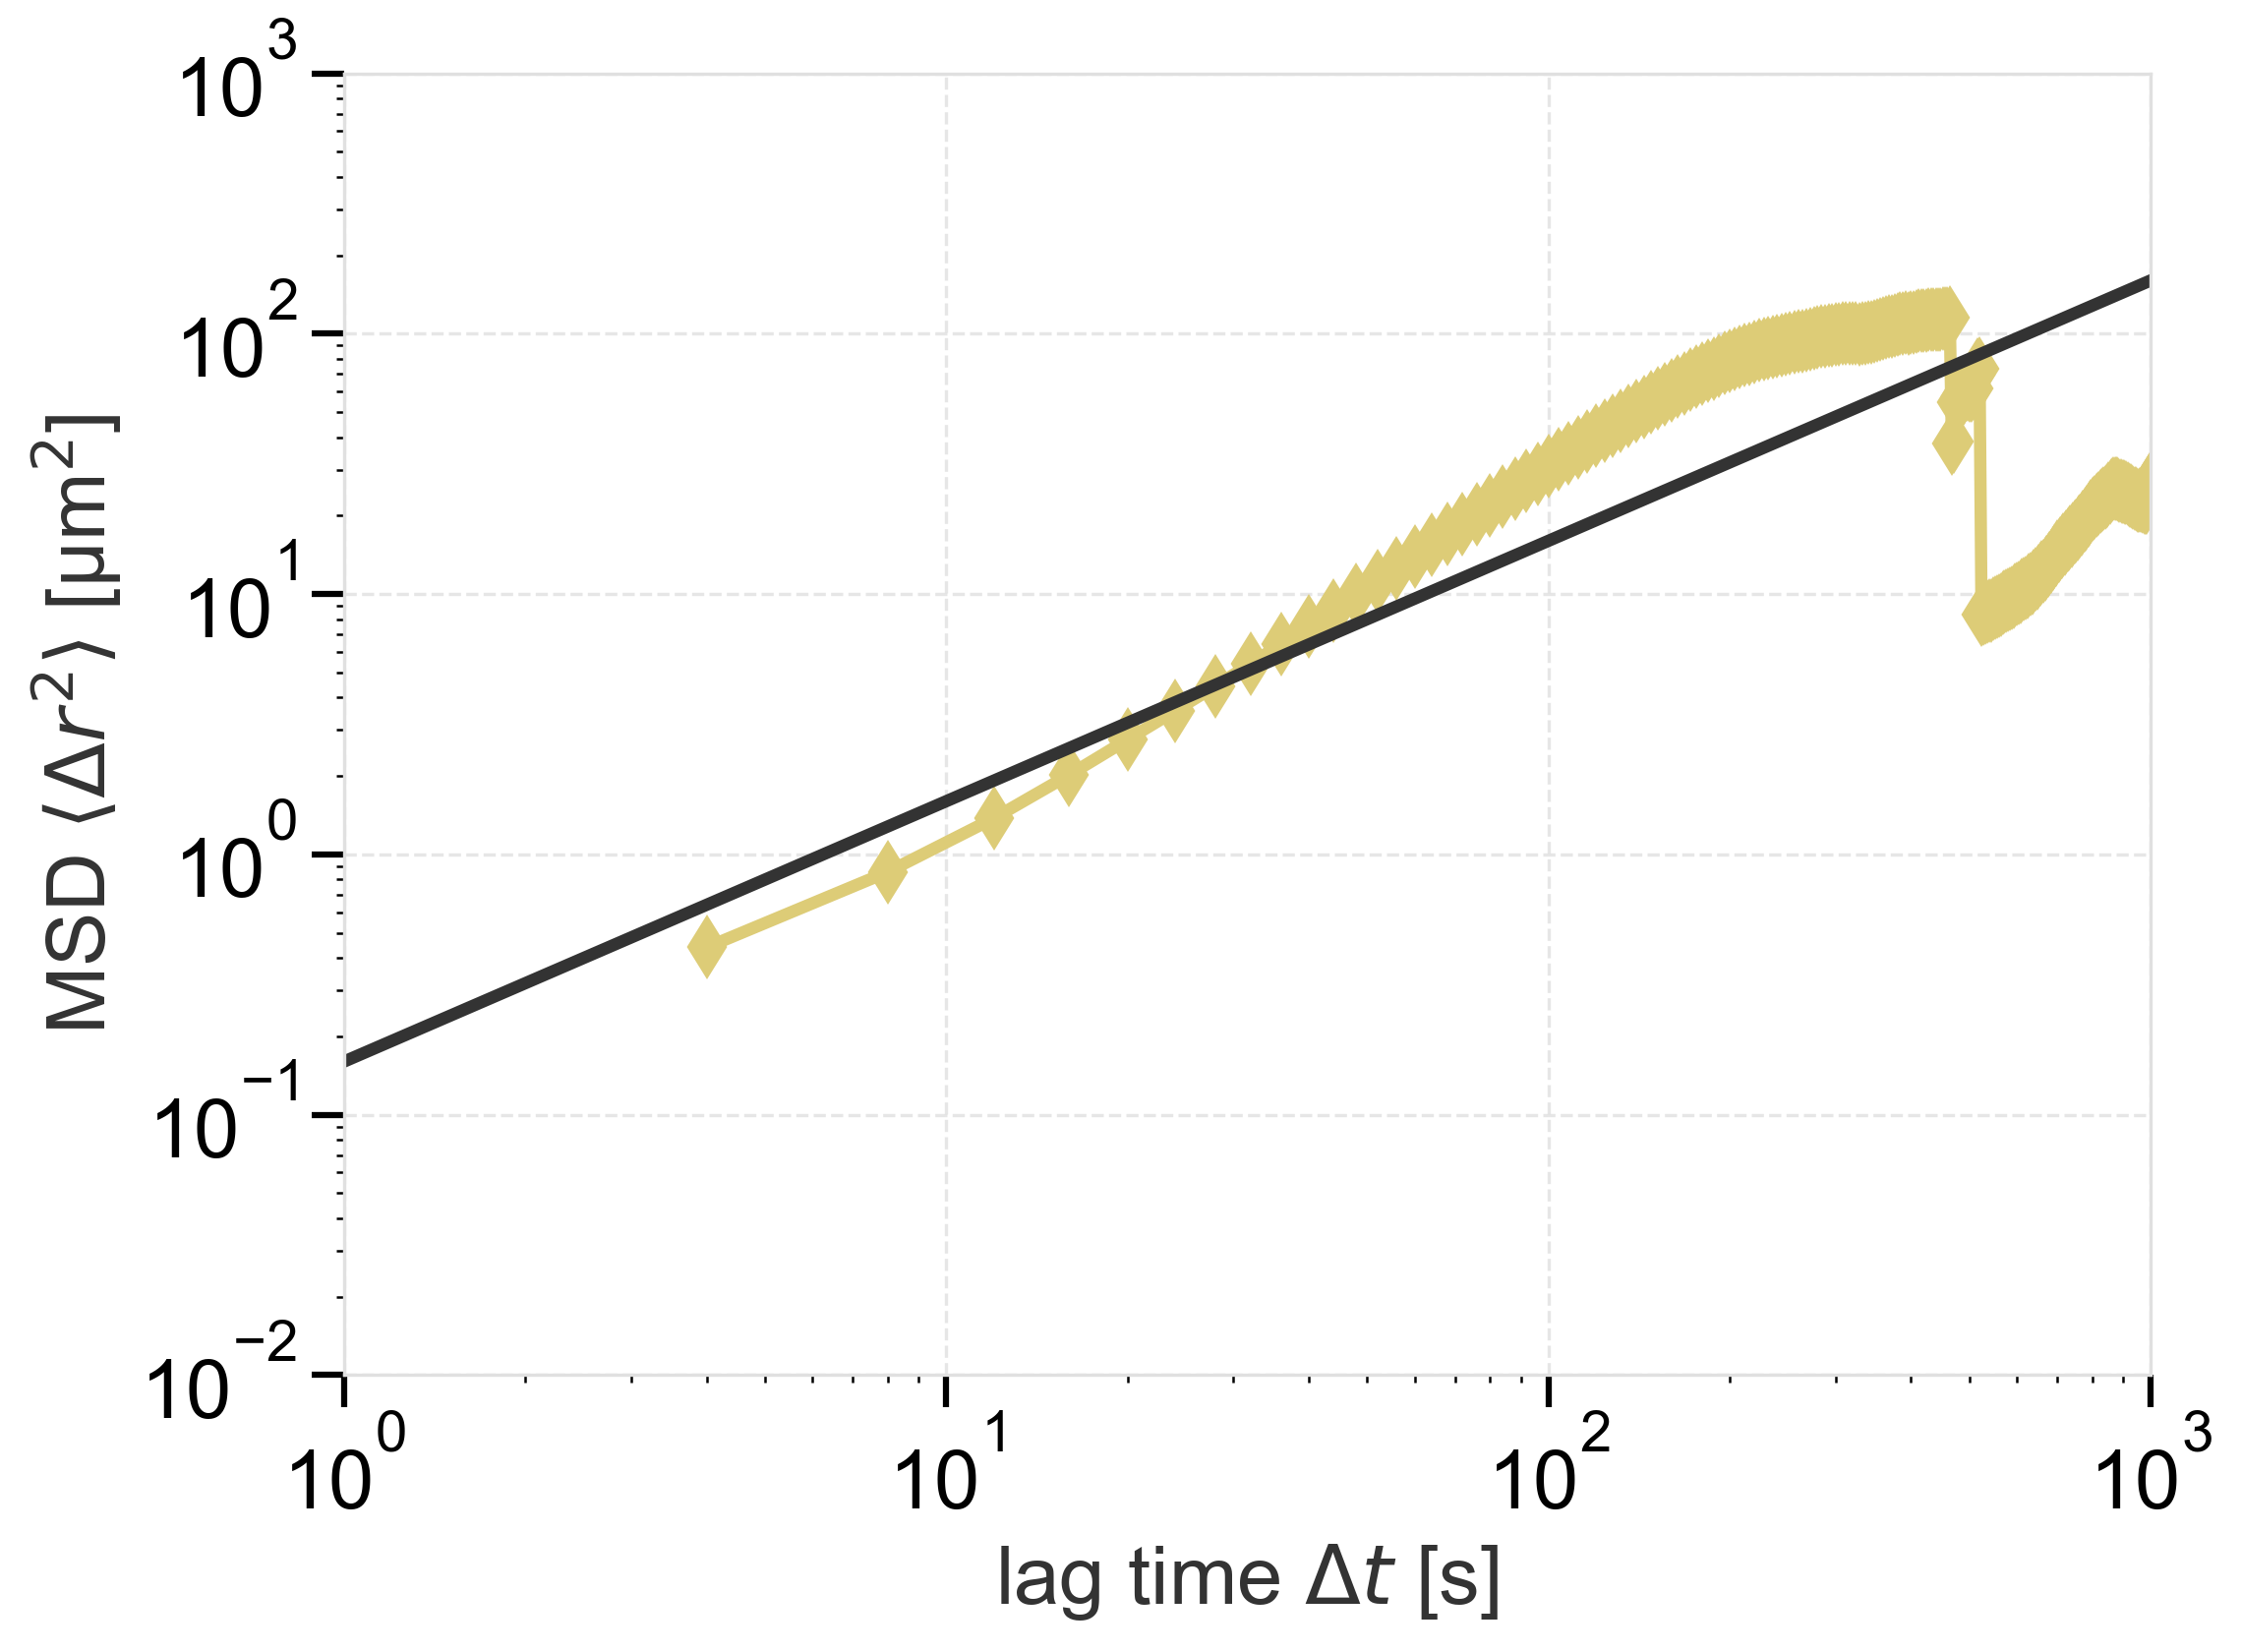

In [13]:
msd5um = concatMSD(mypass / "beads5um", [4, 4, 4])
emsd_5um, err_5um, N_5um = calc_MSD(msd5um)
R=5

scale = 0.11

alpha = 1
marker_size = 10

min_t = 60
max_t = 200

D=0.2/R
x_range = np.linspace(1, 1e3, 1000)

fig, ax = plt.subplots()
ax.plot(emsd_5um.index, emsd_5um, marker='d', label=f'5 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[2])
ax.plot(x_range, 4*D*x_range, color="#333333")

ax.set(
        xlim=(1e-0, 1000),
        ylim=(1e-2, 1e3),
        xscale='log',
        yscale='log',
        xlabel='lag time $\Delta t$ [s]',
        ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
        )

[(1.0, 1000.0),
 (0.01, 1000.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta t$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ [μm$^2$]')]

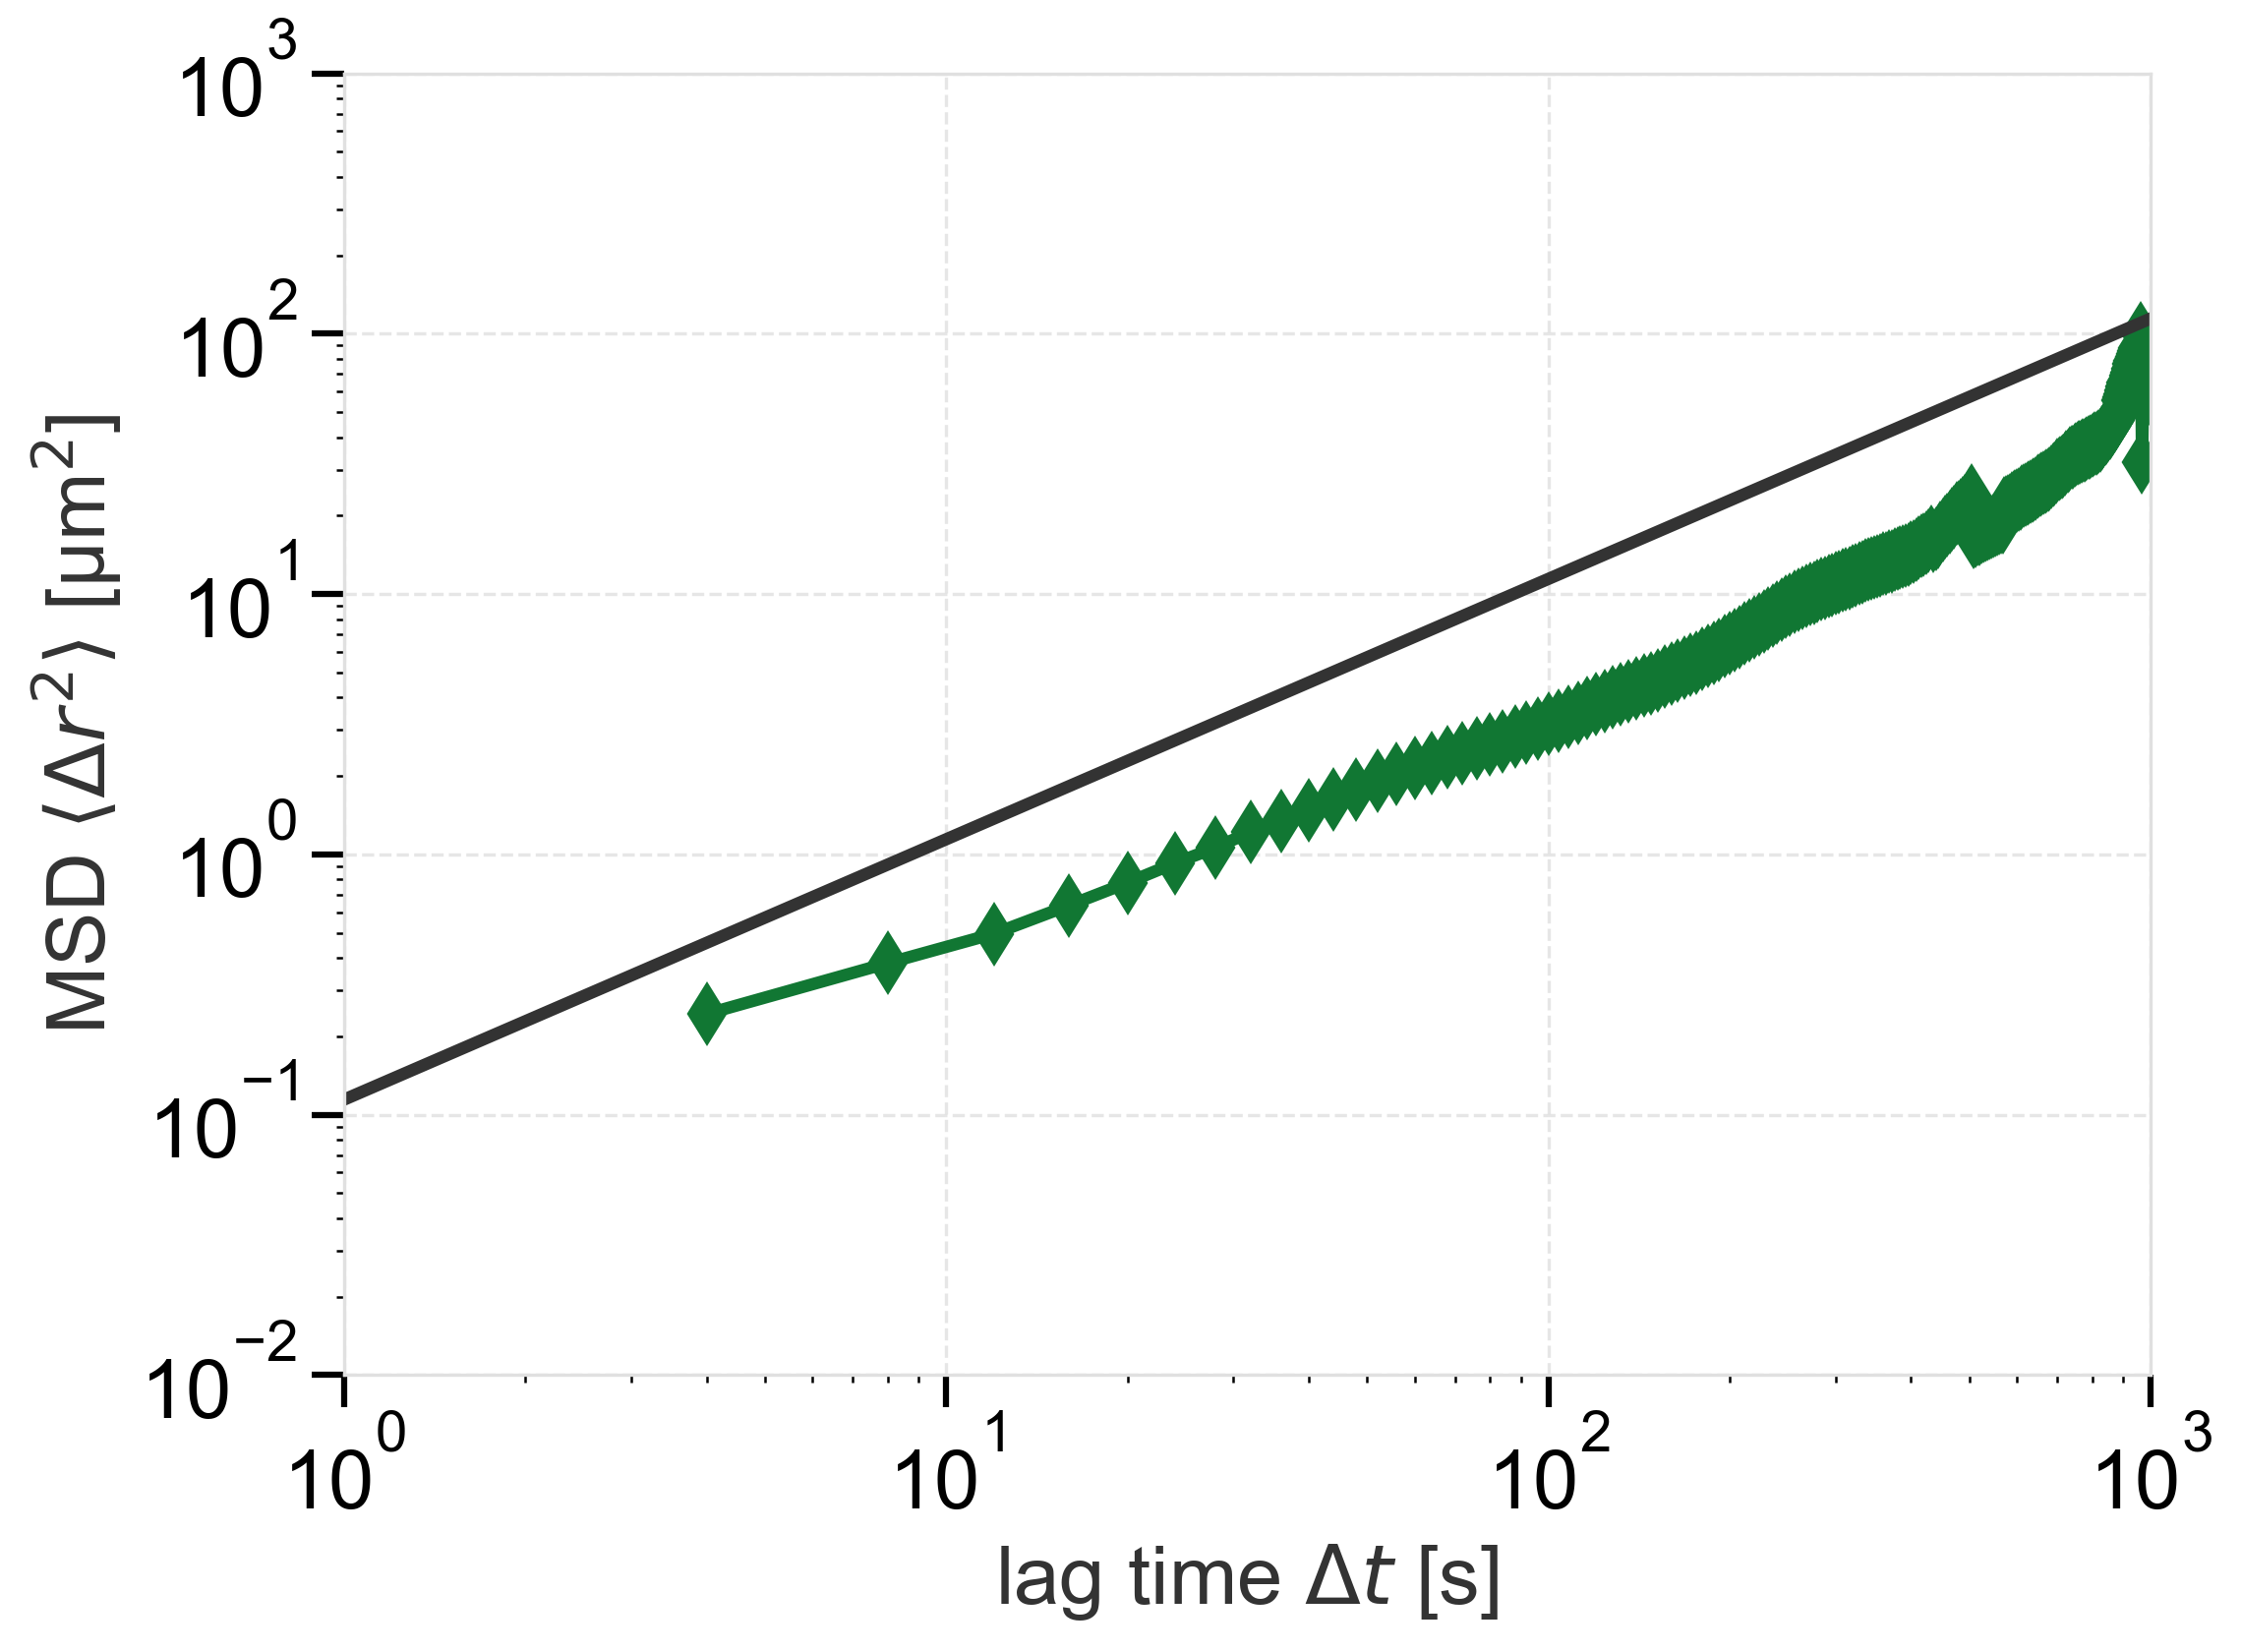

In [14]:
msd7um = concatMSD(mypass / "beads7um", [4, 4, 4])
emsd_7um, err_7um, N_7um = calc_MSD(msd7um)
R=7

scale = 0.11

alpha = 1
marker_size = 10

min_t = 60
max_t = 200

D=0.2/R
x_range = np.linspace(1, 1e3, 1000)

fig, ax = plt.subplots()
ax.plot(emsd_7um.index, emsd_7um, marker='d', label=f'7.24 \u03bcm', alpha = alpha, markersize = marker_size, color=style_colors[3])
ax.plot(x_range, 4*D*x_range, color="#333333")

ax.set(
        xlim=(1e-0, 1000),
        ylim=(1e-2, 1e3),
        xscale='log',
        yscale='log',
        xlabel='lag time $\Delta t$ [s]',
        ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
        )

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [35]:
mypass = Path('/Volumes/data/Sasaki/MTSingleBeads')

def concat_velocity(folder):
    velocity_list = []
    for i in glob.glob(str(Path(folder) / "*" / "*" /"velocities_mean.csv")):
        df = pd.read_csv(i)
        velocity = df['mean_velocity'][0:100].mean()
        velocity_list.append(velocity)

    return np.array(velocity_list)



In [36]:
mypass = Path('/Volumes/data/Sasaki/MTSingleBeads')

v1um = concat_velocity(mypass / "beads1um")
v3um = concat_velocity(mypass / "beads3um")
v5um = concat_velocity(mypass / "beads5um")
v7um = concat_velocity(mypass / "beads7um")

print("beads1um  MTs velocity:", np.mean(v1um), "+-", np.std(v1um))
print("beads3um  MTs velocity:", np.mean(v3um), "+-", np.std(v3um))
print("beads5um  MTs velocity:", np.mean(v5um), "+-", np.std(v5um))
print("beads7um  MTs velocity:", np.mean(v7um), "+-", np.std(v7um))

beads1um  MTs velocity: 0.217032020325 +- 0.0207688353531669
beads3um  MTs velocity: 0.16361757459666668 +- 0.04221298303926346
beads5um  MTs velocity: 0.3758548547 +- 0.031360173547484486
beads7um  MTs velocity: 0.38871786793333335 +- 0.04926588253316775
